# 03 Frequency-Domain AI-Generated Image Detection using FFT and ResNet18

## CSE 445: Machine Learning Project

**Project Title:** Robust AI-Generated Image Detection using Hybrid Spatial–Frequency Analysis  
**Student:** Zawed Bin Tariq  
**Student ID:** 2232811642  
**Instructor:** Dr. Mohammad Abdul Qayum  

---

## Notebook Objective

This notebook trains a frequency-domain image classifier.

Instead of using normal RGB images, each image is transformed into a **frequency-domain representation** using the Fast Fourier Transform.

The goal is to test whether hidden frequency artifacts can help distinguish:

- Real images
- AI-generated images

This model will be compared against the RGB ResNet18 baseline from Notebook 2.

# 1. Frequency-Domain Motivation

AI-generated images may look visually realistic in the spatial RGB domain.

However, generative models can introduce subtle artifacts during image synthesis.  
Some of these artifacts may appear more clearly in the frequency domain than in normal RGB pixel space.

## Approach

Each image is processed as follows:

1. Convert RGB image to grayscale.
2. Resize image to `224 × 224`.
3. Apply Fast Fourier Transform.
4. Shift low-frequency components to the center.
5. Compute log magnitude spectrum.
6. Convert the spectrum into a 3-channel image for ResNet18.

This allows a pretrained CNN to learn frequency-domain patterns.

In [6]:
# ============================================================
# 2. Import Required Libraries
# ============================================================

import os
import random
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

warnings.filterwarnings("ignore", category=UserWarning)

print("Libraries imported successfully.")
print("PyTorch version:", torch.__version__)

Libraries imported successfully.
PyTorch version: 2.10.0+cu128


In [7]:
# ============================================================
# 3. Device Configuration
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available. Enable GPU before training.")

Using device: cuda
GPU name: Tesla T4


In [8]:
# ============================================================
# 3. Device Configuration
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available. Enable GPU before training.")

Using device: cuda
GPU name: Tesla T4


# 2. Dataset Loading and Split

The same balanced subset and train/validation/test split strategy from Notebook 1 and Notebook 2 is reused.

Dataset subset:

| Class | Images |
|---|---:|
| Real | 2000 |
| Fake | 2000 |
| **Total** | **4000** |

Split:

| Split | Images |
|---|---:|
| Training | 2400 |
| Validation | 800 |
| Testing | 800 |

In [11]:
# ============================================================
# 4. Reproducibility Setup
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seed fixed at: {SEED}")

Random seed fixed at: 42


In [9]:
# ============================================================
# 5. Load Image Paths - Fast Version
# ============================================================

dataset_root = Path("/kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images")

image_extensions = {".jpg", ".jpeg", ".png", ".webp"}

real_paths = []
fake_paths = []

for split_folder in ["train", "test"]:
    real_dir = dataset_root / split_folder / "real"
    fake_dir = dataset_root / split_folder / "fake"
    
    real_paths.extend([
        p for p in real_dir.iterdir()
        if p.suffix.lower() in image_extensions
    ])
    
    fake_paths.extend([
        p for p in fake_dir.iterdir()
        if p.suffix.lower() in image_extensions
    ])

all_image_paths = real_paths + fake_paths

print(f"Total image files found: {len(all_image_paths)}")
print(f"Real images found: {len(real_paths)}")
print(f"Fake images found: {len(fake_paths)}")

Total image files found: 60000
Real images found: 30000
Fake images found: 30000


In [12]:
# ============================================================
# 6. Balanced Sampling: 2000 Real + 2000 Fake
# ============================================================

N_REAL = 2000
N_FAKE = 2000

real_sample = random.sample(real_paths, N_REAL)
fake_sample = random.sample(fake_paths, N_FAKE)

real_df = pd.DataFrame({
    "image_path": [str(p) for p in real_sample],
    "label": 0,
    "class_name": "real"
})

fake_df = pd.DataFrame({
    "image_path": [str(p) for p in fake_sample],
    "label": 1,
    "class_name": "fake"
})

df = pd.concat([real_df, fake_df], ignore_index=True)
df = shuffle(df, random_state=SEED).reset_index(drop=True)

print("Balanced dataframe created.")
print(df["class_name"].value_counts())

Balanced dataframe created.
class_name
real    2000
fake    2000
Name: count, dtype: int64


In [13]:
# ============================================================
# 7. Train/Validation/Test Split
# ============================================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.40,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Dataset split completed.")

print("\nTrain size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

print("\nClass distribution:")
print("Train:")
print(train_df["class_name"].value_counts())
print("\nValidation:")
print(val_df["class_name"].value_counts())
print("\nTest:")
print(test_df["class_name"].value_counts())

Dataset split completed.

Train size: 2400
Validation size: 800
Test size: 800

Class distribution:
Train:
class_name
real    1200
fake    1200
Name: count, dtype: int64

Validation:
class_name
real    400
fake    400
Name: count, dtype: int64

Test:
class_name
real    400
fake    400
Name: count, dtype: int64


# 3. FFT Magnitude Spectrum Transformation

The following function converts an image into its FFT magnitude spectrum.

The output is normalized to the range `[0, 255]` and converted into a PIL image.  
Since ResNet18 expects 3-channel input, the single-channel FFT image is converted into RGB format.

In [14]:
# ============================================================
# 8. FFT Magnitude Spectrum Function
# ============================================================

def image_to_fft_pil(image_path, image_size=(224, 224)):
    image = Image.open(image_path).convert("L")
    image = image.resize(image_size)
    
    image_array = np.array(image)
    
    fft = np.fft.fft2(image_array)
    fft_shift = np.fft.fftshift(fft)
    magnitude = np.log1p(np.abs(fft_shift))
    
    magnitude = magnitude - magnitude.min()
    magnitude = magnitude / (magnitude.max() + 1e-8)
    magnitude = (magnitude * 255).astype(np.uint8)
    
    fft_image = Image.fromarray(magnitude).convert("RGB")
    
    return fft_image

print("FFT transformation function defined successfully.")

FFT transformation function defined successfully.


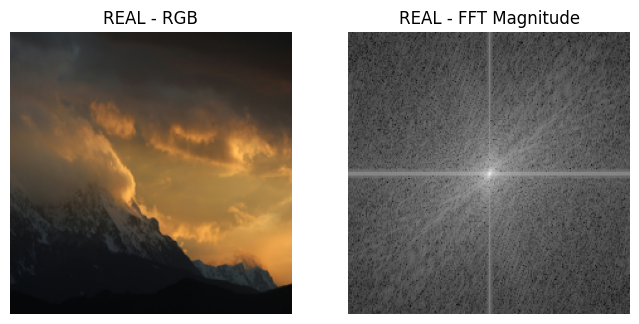

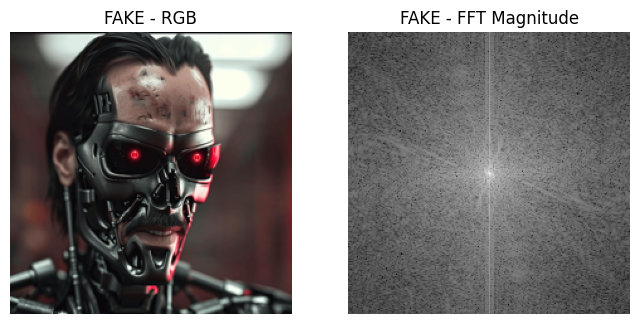

In [15]:
# ============================================================
# 9. Visual Sanity Check: RGB vs FFT
# ============================================================

def show_rgb_vs_fft(dataframe, class_name):
    sample = dataframe[dataframe["class_name"] == class_name].sample(n=1, random_state=SEED).iloc[0]
    image_path = sample["image_path"]
    
    rgb_image = Image.open(image_path).convert("RGB").resize((224, 224))
    fft_image = image_to_fft_pil(image_path)
    
    plt.figure(figsize=(8, 4))
    
    plt.subplot(1, 2, 1)
    plt.imshow(rgb_image)
    plt.title(f"{class_name.upper()} - RGB")
    plt.axis("off")
    
    plt.subplot(1, 2, 2)
    plt.imshow(fft_image, cmap="gray")
    plt.title(f"{class_name.upper()} - FFT Magnitude")
    plt.axis("off")
    
    plt.show()

show_rgb_vs_fft(train_df, "real")
show_rgb_vs_fft(train_df, "fake")

# 4. Dataset Class for FFT Images

This custom PyTorch Dataset does not return the original RGB image.

Instead, it:

1. Reads the image path.
2. Converts the image to FFT magnitude spectrum.
3. Applies ResNet-compatible transformations.
4. Returns the transformed FFT image and label.

In [16]:
# ============================================================
# 10. Image Transformations for FFT Images
# ============================================================

IMG_SIZE = 224

fft_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("FFT image transformations defined.")

FFT image transformations defined.


In [17]:
# ============================================================
# 11. PyTorch Dataset Class for FFT Images
# ============================================================

class FFTImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        image_path = self.dataframe.loc[idx, "image_path"]
        label = int(self.dataframe.loc[idx, "label"])
        
        fft_image = image_to_fft_pil(image_path)
        
        if self.transform is not None:
            fft_image = self.transform(fft_image)
        
        return fft_image, label

print("FFT PyTorch Dataset class created.")

FFT PyTorch Dataset class created.


In [19]:
# ============================================================
# 12. Create FFT DataLoaders
# ============================================================

BATCH_SIZE = 32

train_dataset = FFTImageDataset(train_df, transform=fft_transform)
val_dataset = FFTImageDataset(val_df, transform=fft_transform)
test_dataset = FFTImageDataset(test_df, transform=fft_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("FFT DataLoaders created successfully.")
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

FFT DataLoaders created successfully.
Training batches: 75
Validation batches: 25
Testing batches: 25


In [20]:
# ============================================================
# 13. FFT DataLoader Sanity Check
# ============================================================

images, labels = next(iter(train_loader))

print("FFT image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Sample labels:", labels[:10].tolist())

FFT image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Sample labels: [0, 1, 1, 0, 1, 0, 1, 1, 0, 0]


# 5. Frequency-Domain ResNet18 Model

A pretrained ResNet18 model is used to classify FFT magnitude spectrum images.

Although ResNet18 was originally trained on RGB natural images, the FFT magnitude spectrum is converted into a 3-channel image so that the same architecture can be used.

This model tests whether frequency-domain information alone is useful for detecting AI-generated images.

In [21]:
# ============================================================
# 14. ResNet18 Model Setup for FFT Images
# ============================================================

fft_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_features = fft_model.fc.in_features
fft_model.fc = nn.Linear(num_features, 2)

fft_model = fft_model.to(device)

print("ResNet18 model for FFT images loaded successfully.")
print("Final layer:", fft_model.fc)
print("Model device:", next(fft_model.parameters()).device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 198MB/s]


ResNet18 model for FFT images loaded successfully.
Final layer: Linear(in_features=512, out_features=2, bias=True)
Model device: cuda:0


In [22]:
# ============================================================
# 15. Loss Function and Optimizer
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    fft_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print("Loss function and optimizer defined.")

Loss function and optimizer defined.


# 6. Training and Validation Functions

The FFT ResNet18 model is trained using cross-entropy loss.

For each epoch:

1. The model learns from FFT images in the training set.
2. The model is evaluated on the validation set.
3. Training and validation loss/accuracy are recorded.

The validation set is used only for model selection, not direct learning.

In [24]:
# ============================================================
# 16. Training Function
# ============================================================

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        
        _, preds = torch.max(outputs, 1)
        correct_predictions += (preds == labels).sum().item()
        total_samples += labels.size(0)
    
    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    
    return epoch_loss, epoch_accuracy

In [25]:
# ============================================================
# 17. Evaluation Function
# ============================================================

def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    all_labels = []
    all_predictions = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            
            _, preds = torch.max(outputs, 1)
            correct_predictions += (preds == labels).sum().item()
            total_samples += labels.size(0)
            
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(preds.cpu().numpy())
    
    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    
    return epoch_loss, epoch_accuracy, all_labels, all_predictions

# 7. Model Training

The frequency-domain ResNet18 model is trained for 5 epochs.

This experiment checks whether FFT magnitude spectrum images contain useful patterns for distinguishing real and AI-generated images.

In [26]:
# ============================================================
# 18. Train FFT ResNet18 Model
# ============================================================

NUM_EPOCHS = 5

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_accuracy = 0.0
best_model_path = "/kaggle/working/best_resnet18_fft_baseline.pth"

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")
    print("-" * 30)
    
    train_loss, train_acc = train_one_epoch(
        fft_model,
        train_loader,
        criterion,
        optimizer,
        device
    )
    
    val_loss, val_acc, _, _ = evaluate_model(
        fft_model,
        val_loader,
        criterion,
        device
    )
    
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Accuracy:   {val_acc:.4f}")
    
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save(fft_model.state_dict(), best_model_path)
        print("Best FFT model saved.")

end_time = time.time()
training_time = end_time - start_time

print("\nTraining completed.")
print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")
print(f"Training Time: {training_time / 60:.2f} minutes")


Epoch 1/5
------------------------------
Train Loss: 0.6541 | Train Accuracy: 0.6217
Val Loss:   0.6225 | Val Accuracy:   0.6650
Best FFT model saved.

Epoch 2/5
------------------------------
Train Loss: 0.3118 | Train Accuracy: 0.8829
Val Loss:   0.7930 | Val Accuracy:   0.6550

Epoch 3/5
------------------------------
Train Loss: 0.0747 | Train Accuracy: 0.9842
Val Loss:   0.9013 | Val Accuracy:   0.6700
Best FFT model saved.

Epoch 4/5
------------------------------
Train Loss: 0.0331 | Train Accuracy: 0.9929
Val Loss:   1.1158 | Val Accuracy:   0.6600

Epoch 5/5
------------------------------
Train Loss: 0.0413 | Train Accuracy: 0.9854
Val Loss:   1.2935 | Val Accuracy:   0.6225

Training completed.
Best Validation Accuracy: 0.6700
Training Time: 12.80 minutes


# 8. Test Set Evaluation

The best frequency-domain model checkpoint is loaded and evaluated on the unseen test set.

Although the validation accuracy is lower than the RGB baseline, this experiment is important because it measures whether FFT magnitude spectra alone can separate real and AI-generated images.

In [27]:
# ============================================================
# 19. Load Best FFT Model and Evaluate on Test Set
# ============================================================

fft_model.load_state_dict(torch.load(best_model_path, map_location=device))
fft_model = fft_model.to(device)

test_loss, test_acc, test_labels, test_preds = evaluate_model(
    fft_model,
    test_loader,
    criterion,
    device
)

print("FFT test evaluation completed.")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

FFT test evaluation completed.
Test Loss:     0.9215
Test Accuracy: 0.6500


# 9. Classification Metrics

The FFT baseline is evaluated using the same metrics as the RGB baseline:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

Using the same metrics allows fair comparison between spatial-domain and frequency-domain models.

In [28]:
# ============================================================
# 20. Classification Metrics
# ============================================================

test_accuracy = accuracy_score(test_labels, test_preds)
test_precision = precision_score(test_labels, test_preds)
test_recall = recall_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds)

print("Final FFT Test Metrics:")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    test_labels,
    test_preds,
    target_names=["Real", "Fake"]
))

Final FFT Test Metrics:
Accuracy : 0.6500
Precision: 0.6322
Recall   : 0.7175
F1-score : 0.6721

Classification Report:
              precision    recall  f1-score   support

        Real       0.67      0.58      0.62       400
        Fake       0.63      0.72      0.67       400

    accuracy                           0.65       800
   macro avg       0.65      0.65      0.65       800
weighted avg       0.65      0.65      0.65       800



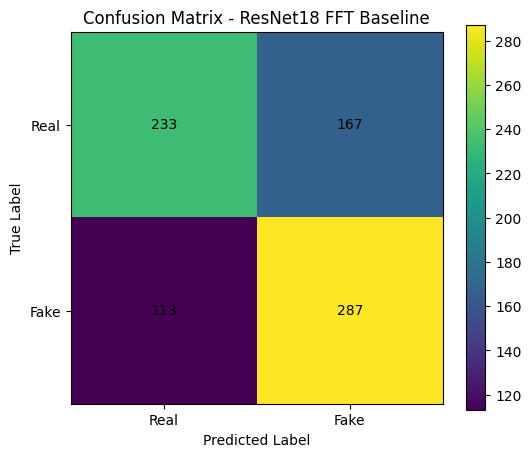

Confusion Matrix:
[[233 167]
 [113 287]]


In [29]:
# ============================================================
# 21. Confusion Matrix
# ============================================================

cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix - ResNet18 FFT Baseline")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["Real", "Fake"])
plt.yticks([0, 1], ["Real", "Fake"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

print("Confusion Matrix:")
print(cm)

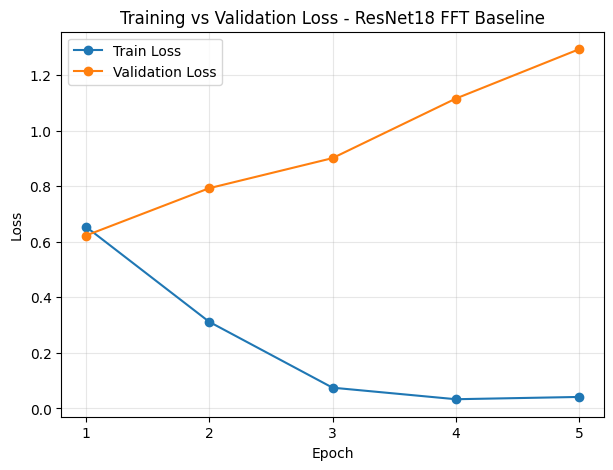

In [30]:
# ============================================================
# 22. Training and Validation Loss Curve
# ============================================================

epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
plt.title("Training vs Validation Loss - ResNet18 FFT Baseline")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(list(epochs))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

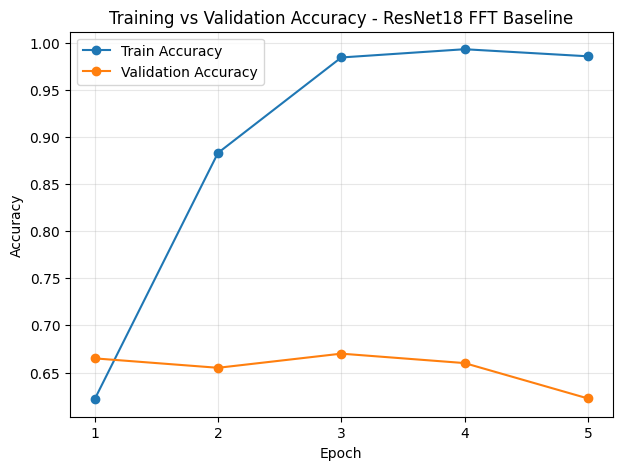

In [31]:
# ============================================================
# 23. Training and Validation Accuracy Curve
# ============================================================

plt.figure(figsize=(7, 5))
plt.plot(epochs, history["train_accuracy"], marker="o", label="Train Accuracy")
plt.plot(epochs, history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Training vs Validation Accuracy - ResNet18 FFT Baseline")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(list(epochs))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [32]:
# ============================================================
# 24. Save FFT Baseline Results
# ============================================================

results = {
    "model": ["ResNet18_FFT_Baseline"],
    "input_type": ["FFT_Magnitude"],
    "best_val_accuracy": [best_val_accuracy],
    "test_accuracy": [test_accuracy],
    "test_precision": [test_precision],
    "test_recall": [test_recall],
    "test_f1_score": [test_f1],
    "test_loss": [test_loss],
    "epochs": [NUM_EPOCHS],
    "training_time_minutes": [training_time / 60]
}

results_df = pd.DataFrame(results)

results_path = "/kaggle/working/resnet18_fft_baseline_results.csv"
results_df.to_csv(results_path, index=False)

print("FFT results saved successfully.")
print(results_df)

FFT results saved successfully.
                   model     input_type  best_val_accuracy  test_accuracy  \
0  ResNet18_FFT_Baseline  FFT_Magnitude               0.67           0.65   

   test_precision  test_recall  test_f1_score  test_loss  epochs  \
0        0.632159       0.7175       0.672131   0.921494       5   

   training_time_minutes  
0              12.803927  


In [33]:
# ============================================================
# 25. Save FFT Training History
# ============================================================

history_df = pd.DataFrame(history)
history_df["epoch"] = range(1, NUM_EPOCHS + 1)

history_path = "/kaggle/working/resnet18_fft_training_history.csv"
history_df.to_csv(history_path, index=False)

print("FFT training history saved successfully.")
print(history_df)

FFT training history saved successfully.
   train_loss  train_accuracy  val_loss  val_accuracy  epoch
0    0.654135        0.621667  0.622510        0.6650      1
1    0.311752        0.882917  0.793037        0.6550      2
2    0.074655        0.984167  0.901317        0.6700      3
3    0.033083        0.992917  1.115760        0.6600      4
4    0.041288        0.985417  1.293488        0.6225      5


# 10. Result Interpretation

The FFT-only ResNet18 baseline achieved lower validation performance than the RGB ResNet18 baseline.

## Key Observation

The model rapidly reached very high training accuracy but validation accuracy remained low.

This indicates strong overfitting to the training FFT magnitude spectra.

## Interpretation

The result suggests that FFT magnitude spectra alone are not sufficient for robust classification in this simplified baseline setup.

However, this does not mean frequency information is useless.  
Instead, it suggests that frequency features may need to be combined with spatial RGB features or learned using more specialized frequency-aware architectures.

This observation is consistent with recent frequency-aware detection literature, where frequency information is usually used through specialized modules or fused with spatial features rather than used as a standalone raw input.

## Conclusion

The FFT baseline provides an important ablation experiment.

It shows that:

1. RGB spatial features are stronger than raw FFT-only features in this setup.
2. FFT features may still contain complementary information.
3. The next step should be a hybrid spatial-frequency fusion model.

# Final Interpretation

The FFT-only ResNet18 baseline achieved a test accuracy of 65.00% and an F1-score of 67.21%. Although the model rapidly achieved very high training accuracy, validation and test performance remained much lower. This indicates that the model overfit to training-specific FFT magnitude patterns.

This result is important because it shows that raw FFT magnitude spectra alone are not sufficient for robust classification in this simplified setup. However, it does not reject the usefulness of frequency information. Instead, it motivates the next stage of the project: spatial-frequency fusion.

Recent frequency-aware studies suggest that spectral artifacts can be useful for detection, but they should be learned through specialized modules or fused with spatial representations rather than used as a standalone raw input. Therefore, the next experiment combines RGB spatial features with FFT-based frequency features in a hybrid model.